# Make Figures

Kendra Wyant  
June 2, 2026

In [ ]:

suppressMessages(library(tidyverse))
suppressMessages(library(tidymodels))
suppressMessages(library(patchwork))
suppressMessages(library(binom))
options(scipen = 999)

devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "0faa14c0c44c2635216370888b7da9bfa8d07979"

### Fairness

ℹ In argument: `group = case_match(...)`.
Caused by warning:
! `case_match()` was deprecated in dplyr 1.2.0.
ℹ Please use `recode_values()` instead.

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?

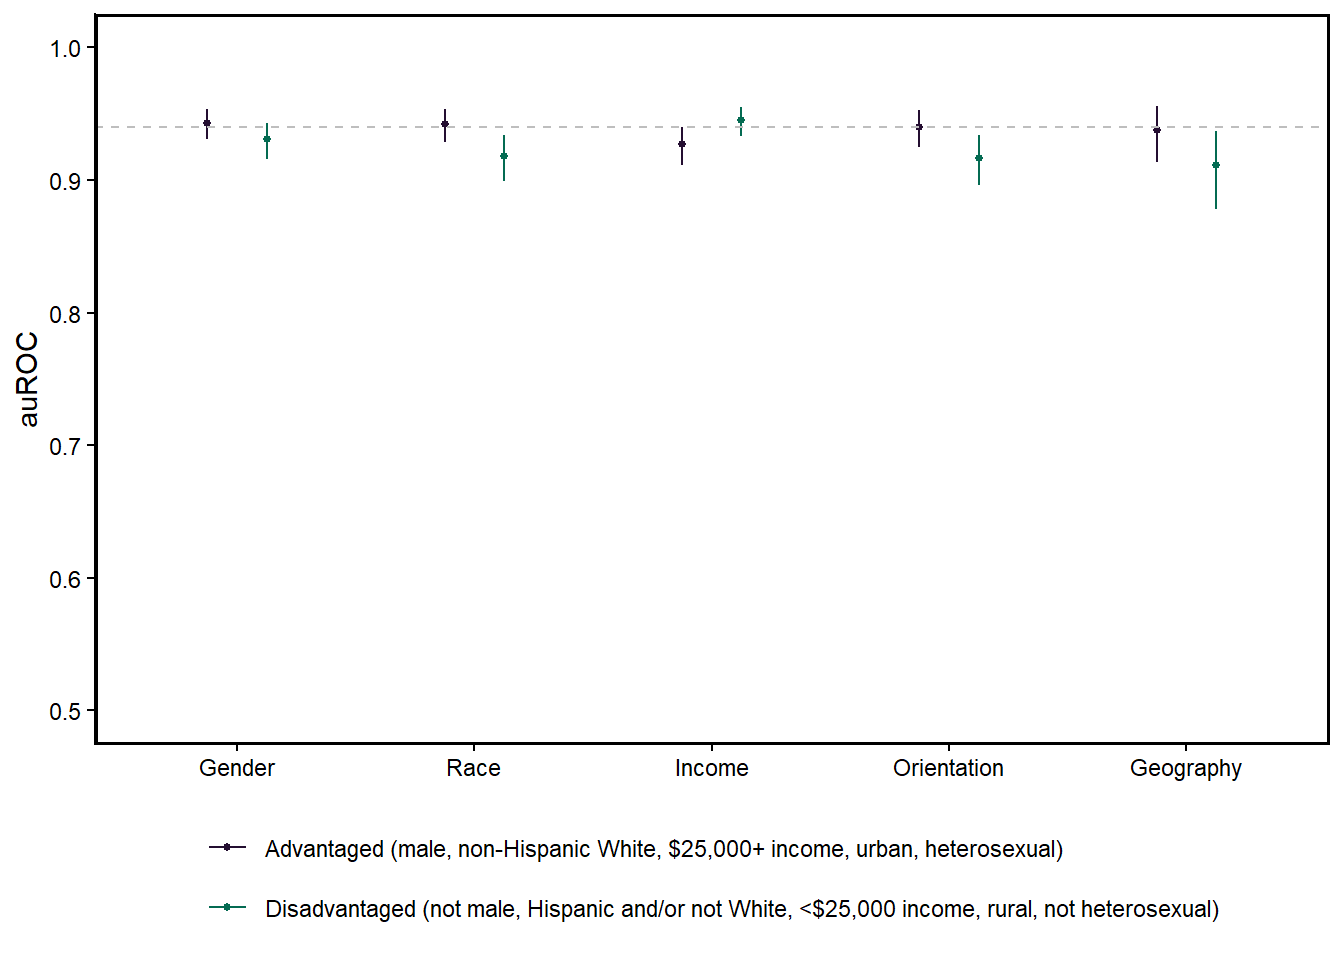

In [ ]:

pp_dem |>
  mutate(group = case_match(model,
                               "male" ~ "Gender",
                               "not male" ~ "Gender",
                               "non-Hispanic White" ~ "Race",
                               "Hispanic and/or not white" ~ "Race",
                               "below poverty" ~ "Income",
                               "above poverty" ~ "Income",
                               "urban/suburban" ~ "Geography",
                               "small town/rural" ~ "Geography",
                               "heterosexual" ~ "Orientation",
                               "not heterosexual" ~ "Orientation"),
         fairness = if_else(model %in% c("not male", 
                                         "Hispanic and/or not white",
                                         "below poverty",
                                         "small town/rural",
                                         "not heterosexual"), 
                            "Disadvantaged (not male, Hispanic and/or not White, <$25,000 income, rural, not heterosexual)",
                            "Advantaged (male, non-Hispanic White, $25,000+ income, urban, heterosexual)"),
         fairness = factor(fairness),
         group = factor(group, levels = c("Gender", "Race",
                                                "Income", "Orientation", "Geography"))) |>  
  ggplot(aes(x = group, y = pp_median, color = fairness)) + 
  geom_point(position = position_dodge(width = 0.5), size = 1) +
  geom_line(position = position_dodge(width = 0.5)) +
  geom_segment(mapping = aes(x = group, y = pp_lower, yend = pp_upper, color = fairness),
               position = position_dodge(width = 0.5)) +
  scale_y_continuous("auROC", limits = c(.50, 1.0)) +
  labs(x = NULL,
       color = NULL) +
  theme_classic() +
  theme(legend.position = "bottom",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) +
  scale_color_manual(values = c("#240e31", "#046B52")) +
  geom_hline(yintercept = subset(pp_all, model == "full")$pp_median, linetype = "dashed",  color = "grey") +
guides(color = guide_legend(nrow = 2, byrow = TRUE))


### Calibration

In [ ]:

bin_width = 0.10

preds_all_logi <- preds |> 
  mutate(bins = cut(prob_logi, breaks = seq(0, 1, bin_width)), 
         lapse = if_else(label == "Lapse", 1, 0),
         prob = "Platt calibrated")  

preds_all_raw <- preds |> 
  mutate(bins = cut(prob_raw, breaks = seq(0, 1, bin_width)), 
         lapse = if_else(label == "Lapse", 1, 0),
         prob = "Raw (uncalibrated)") 

rug_data_raw <- preds_all_raw |> 
  mutate(
    bins = as.numeric(bins),
    rug_center = bin_width/2 + bin_width * (bins - 1),
    rug_x = rug_center + runif(n(), -bin_width/2, bin_width/2)
  )
rug_data_logi <- preds_all_logi |> 
  mutate(
    bins = as.numeric(bins),
    rug_center = bin_width/2 + bin_width * (bins - 1),
    rug_x = rug_center + runif(n(), -bin_width/2, bin_width/2)
  )


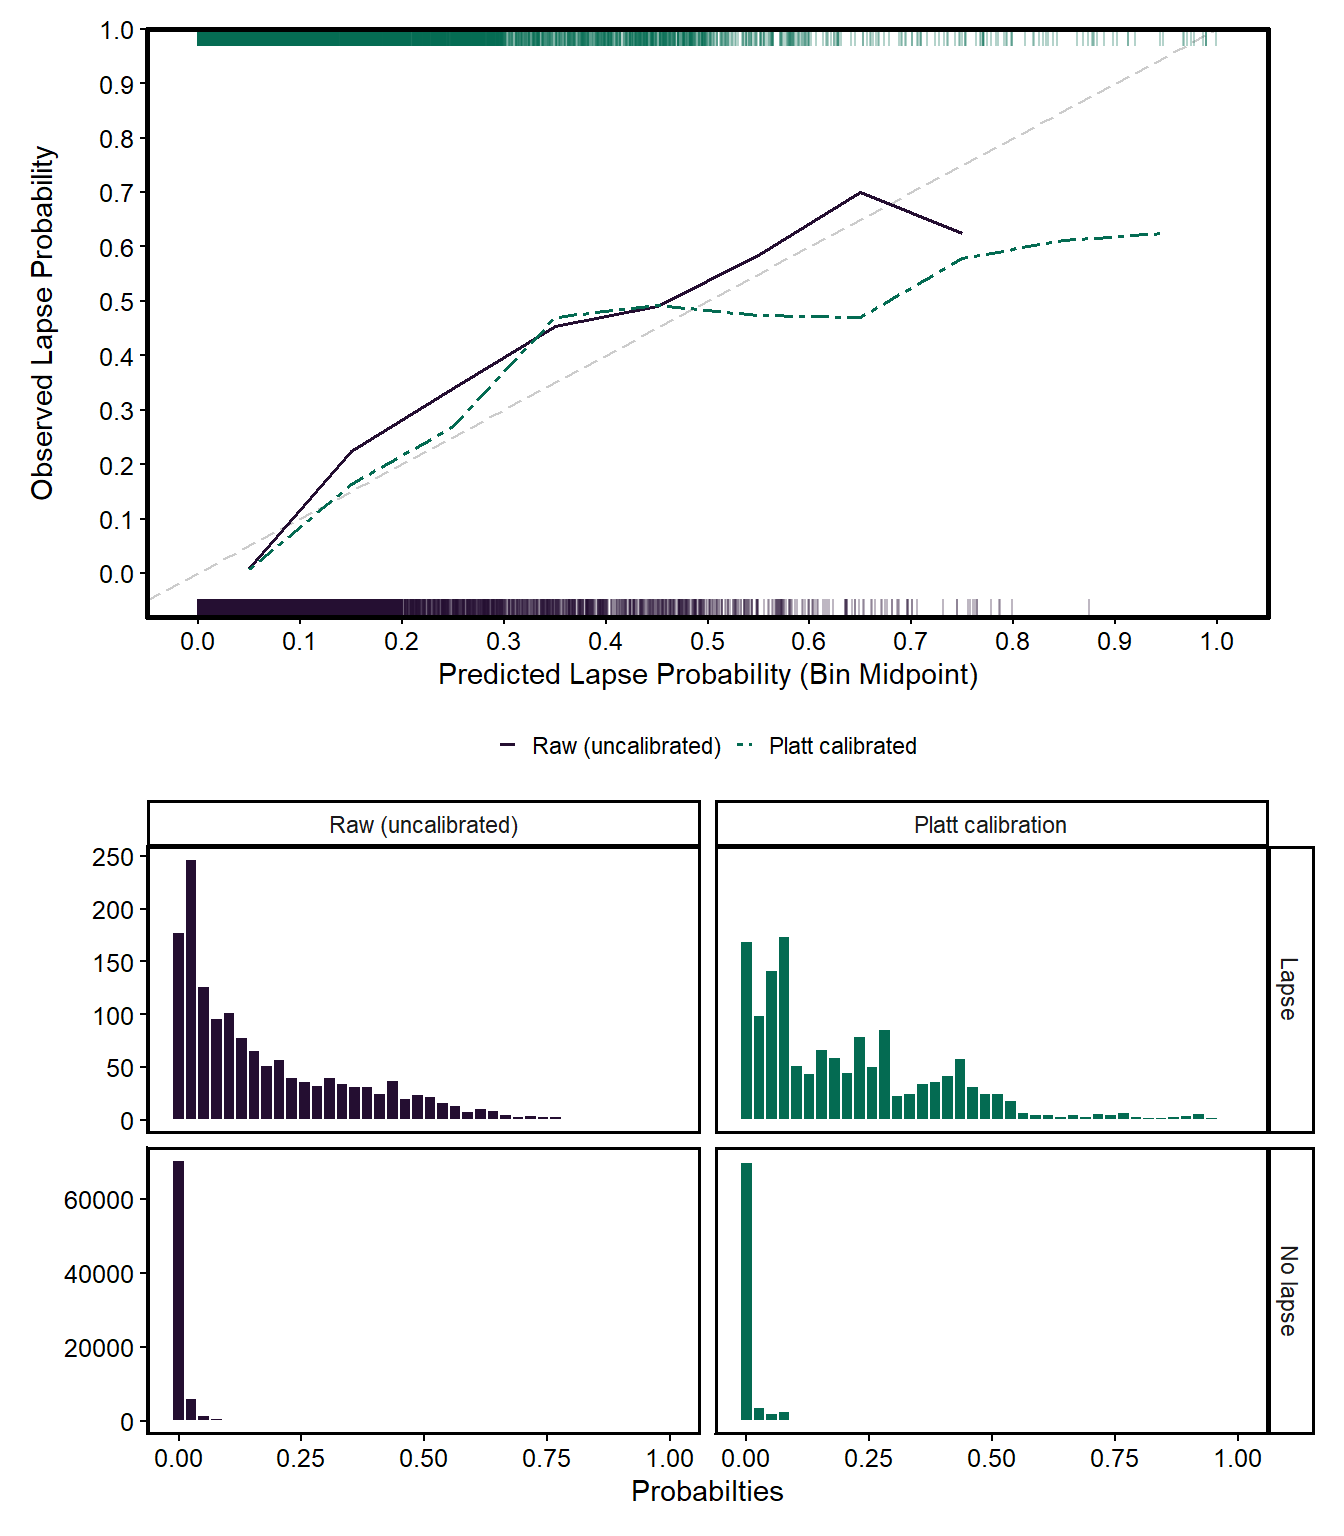

In [ ]:

cal <- preds_all_raw |> 
  bind_rows(preds_all_logi) |> 
  mutate(prob = factor(prob, levels = c("Raw (uncalibrated)", 
                                        "Platt calibrated"))) |> 
  group_by(bins,  prob)  |> 
  summarize(mean_lapse = mean(lapse),
            n = n(),
            .groups = "drop") |> 
  filter(n >= 10) |> 
  select(-n) |> 
  mutate(
    bins = as.numeric(bins),
    midpoints = bin_width/2 + bin_width * (bins - 1)
  )  |> 
  ggplot(aes(x = midpoints, y = mean_lapse, group = prob,
             color = prob, linetype = prob)) +
  geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "gray80") +
  geom_line(linewidth = .7) +
  labs(
    x = "Predicted Lapse Probability (Bin Midpoint)",
    y = "Observed Lapse Probability",
    color = NULL,
    linetype = NULL
  ) +
  geom_rug(data = rug_data_raw, aes(x = rug_x, y = NULL), sides = "b", alpha = 0.3,
           inherit.aes = FALSE, color = "#240e31") +
  geom_rug(data = rug_data_logi, aes(x = rug_x, y = NULL), sides = "t", alpha = 0.3,
           inherit.aes = FALSE, color = "#046B52") +
  scale_x_continuous(breaks = seq(0, 1, bin_width), limits = c(0, 1)) +
  scale_y_continuous(limits = c(-0.08, 1), breaks = seq(0,1, bin_width),
                     expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  scale_color_manual(values = c("#240e31", "#046B52")) +
  scale_linetype_manual(values = c("solid", "twodash")) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.key.size = unit(0.25, "cm"),
        legend.position = "bottom") 


hist <- preds |> 
  pivot_longer(cols = c(prob_raw, prob_logi), names_to = "prob_type", values_to = "prob") |>
  mutate(prob_type = factor(prob_type, levels = c("prob_raw", "prob_logi"),
                                labels = c("Raw (uncalibrated)", "Platt calibration"))) |> 
  ggplot() +
  geom_histogram(aes(x = prob, fill = prob_type), color = "white", bins = 40) +
  facet_grid(label ~ prob_type, scales = "free_y") +
  labs(x = "Probabilties",
       y = NULL) +
  scale_fill_manual(values = c("#240e31", "#046B52")) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "none")

cal / hist


### Feature Importance

In [ ]:

shap_levels <- shaps |> 
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |> 
  arrange(desc(mean_value)) |> 
  slice_head(n = 20) |> 
  arrange(mean_value) |> 
  pull(variable_grp)

n_obs <- max(shaps$id_obs)

shaps_day_max <- shaps |>
  group_by(id_obs) |>
  slice_max(value) |> 
  group_by(variable_grp) |> 
  summarise(n = n(),
            prop = n/n_obs) |> 
  ungroup() 


global_panel <- shaps |>
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |> 
  filter(variable_grp %in% shap_levels) |> 
  mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |> 
  ggplot(mapping = aes(x = variable_grp, y = mean_value)) +
  geom_bar(fill = "#240e31", 
           stat = "identity", position = "dodge") +
  labs(y = "Mean(|Shapley Value|)",
       x = NULL,
       fill = NULL) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        legend.key.size = unit(0.25, "cm"),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "right") +
  coord_flip()


local_panel <- shaps_day_max |> 
  filter(variable_grp %in% shap_levels) |>
  mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
  ggplot(mapping = aes(x = variable_grp, y = prop)) +
  geom_bar(fill = "#046B52", 
           stat = "identity", position = "dodge") +
  labs(y = "Proportion of days as top feature",
       x = NULL,
       fill = NULL) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        legend.key.size = unit(0.25, "cm"),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "right") +
  coord_flip()


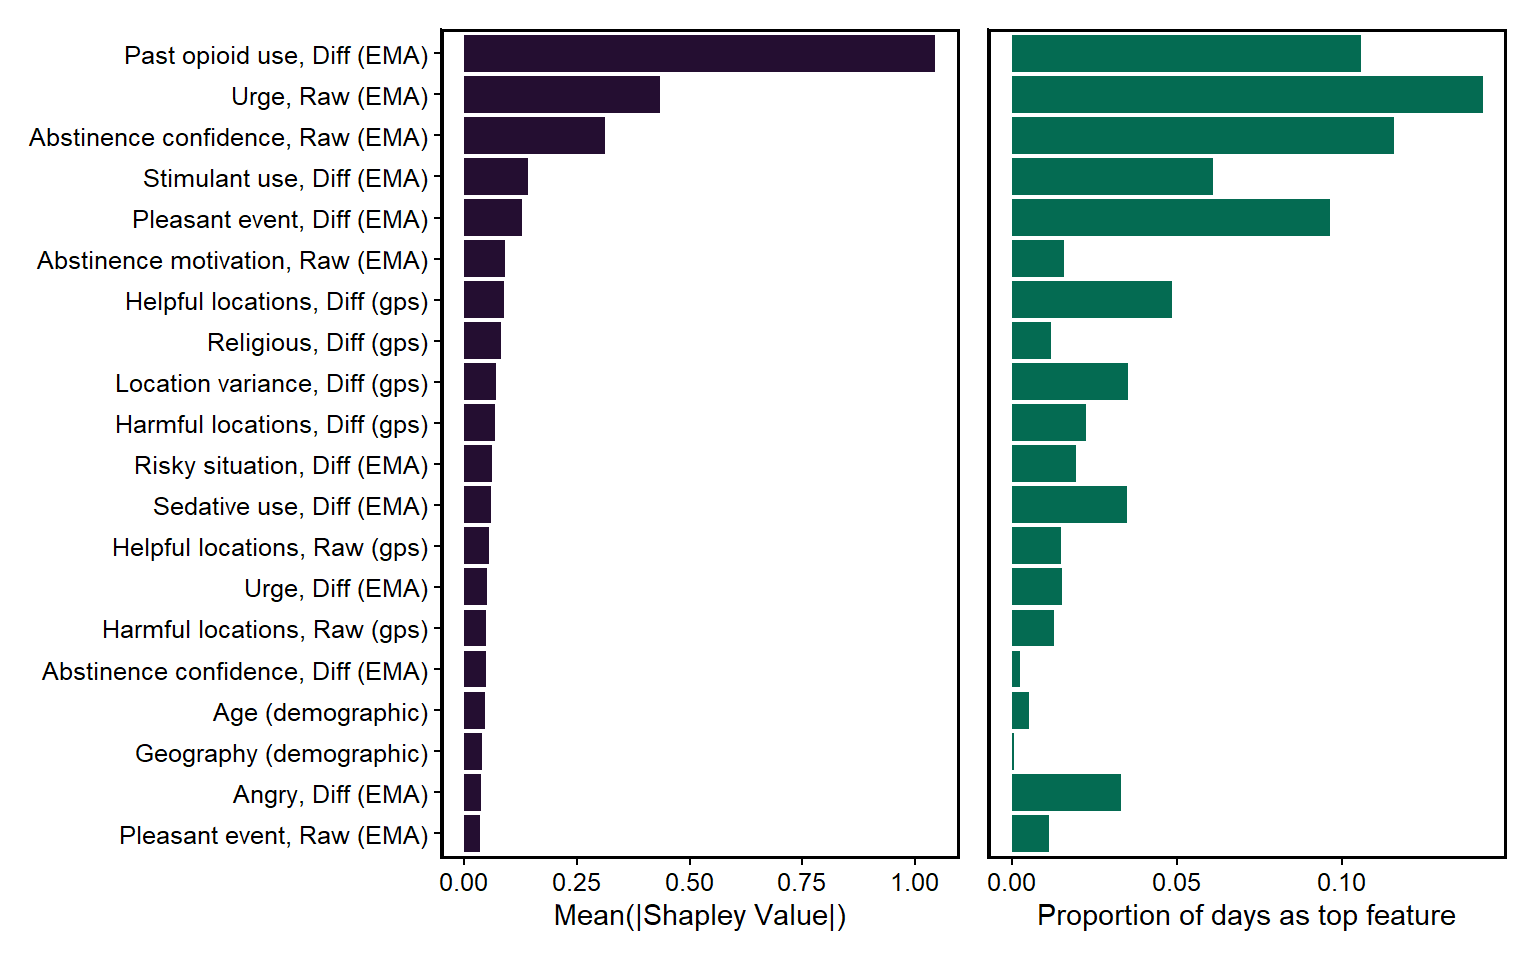

In [ ]:

global_panel + local_panel


Top 20 Individual Shapley plots (about 90 categories total)

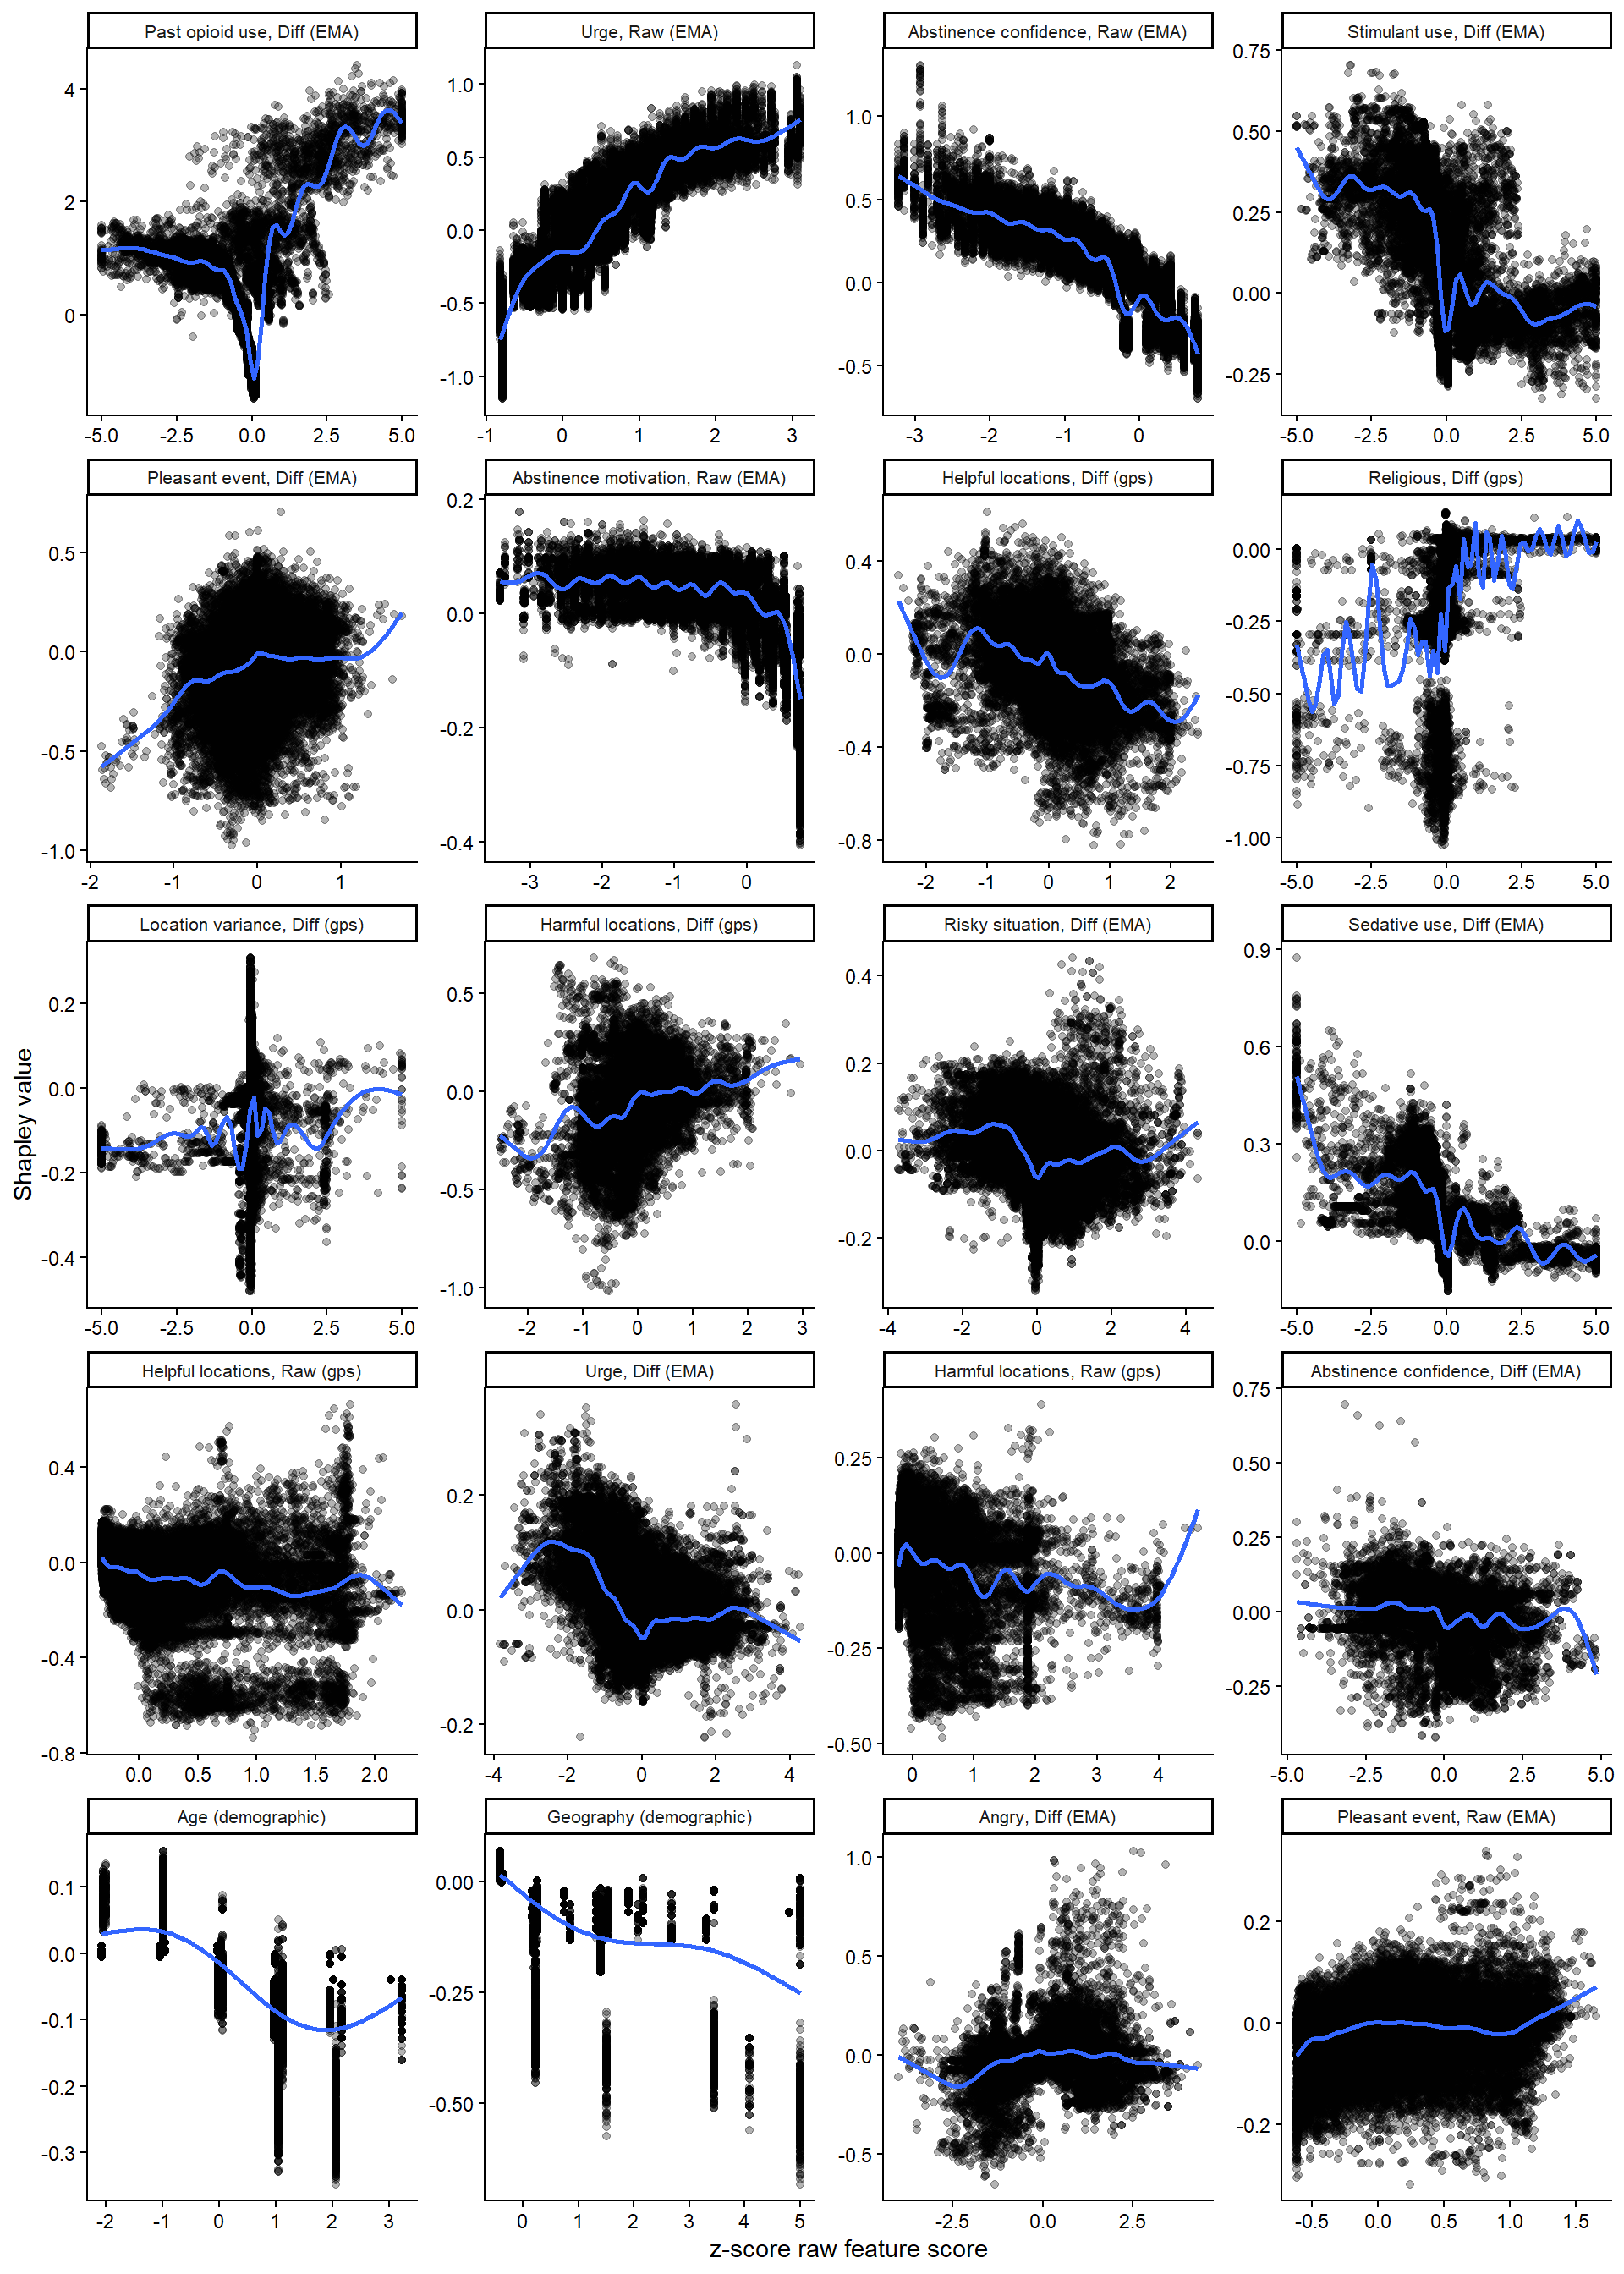

In [ ]:

shap_levels <- shaps |>
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |>
  arrange(desc(mean_value)) |>
  slice_head(n = 20) |>
  pull(variable_grp)

dem_vars <- c("Age (demographic)", "Geography (demographic)")
rel <- "Religious, Diff (gps)"

shaps|>
  filter(variable_grp %in% shap_levels) |>
  mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
  ggplot(aes(x = rfvalue, y = value)) +
  geom_point(alpha = .3) +
  geom_smooth(data = ~ dplyr::filter(.x, !variable_grp %in% c(dem_vars, rel)),
              method = "gam",
              formula = y ~ s(x, k = 20),
              method.args = list(method = "REML"),
              se = FALSE) +
  geom_smooth(data = ~ dplyr::filter(.x, variable_grp %in% dem_vars),
              method = "gam",
              formula = y ~ s(x, k = 4),
              method.args = list(method = "REML"),
              se = FALSE) +
  geom_smooth(data = ~ dplyr::filter(.x, variable_grp %in% rel),
              method = "gam",
              formula = y ~ s(x, k = 40),
              method.args = list(method = "REML"),
              se = FALSE) +
  facet_wrap(~ variable_grp, scales = "free", ncol = 4) +
  labs(
    title = NULL,
    x = "z-score raw feature score",
    y = "Shapley value"
  ) +
  theme_classic() +
  theme(
    strip.text = element_text(size = 8),
    plot.title = element_text(size = 14, face = "bold")
  )

# knitr::include_graphics(path = here::here("figures/shapley_local.png"), error = FALSE)
